# Notebook 11: Análise Socioespacial: Autocorrelação, GWR e Spatial Error Model

O GCI_empírico produz uma superfície de qualidade espacialmente estruturada. Cinco abordagens complementares quantificam essa estrutura e documentam a não-estacionariedade dos determinantes.


In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

gdf = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
print(f'Dataset Enriquecido: {len(gdf):,}')
gdf['GCI'] = gdf['GCI_empirico']  # usa PCI empirico (1/CDI)


Dataset Enriquecido: 1,172,902


## A1. LISA por Setor Censitário

Local Moran's I (Anselin, 1995) com setores censitários (~3.800 polígonos), resolução 8× maior que bairros. Clusters High-High esperados no Centro-Sul e Pampulha (GCI alto, verticalização organizada); Low-Low nas periferias informais.

Setores censitários: 5166


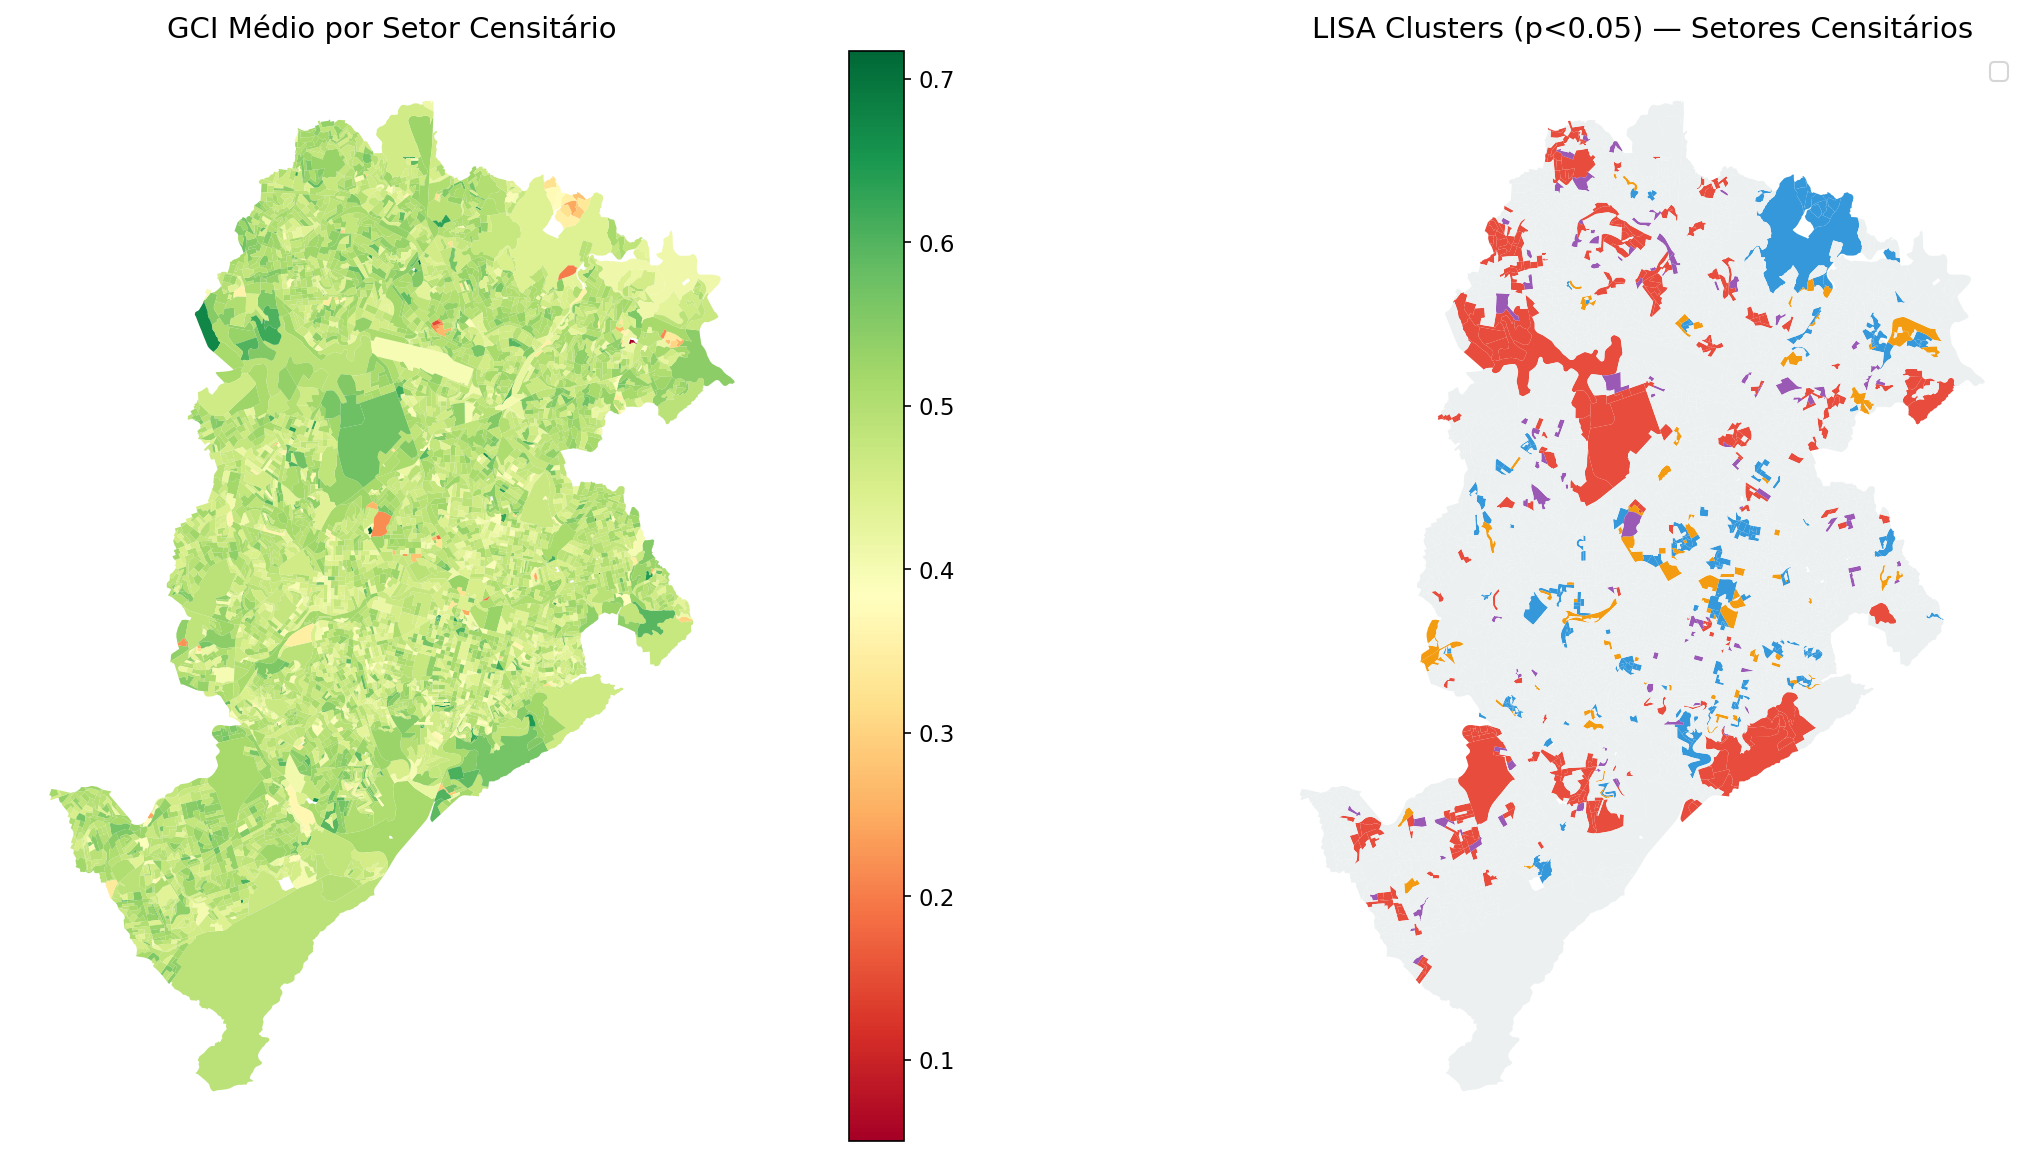


Moran's I Global: 0.1494 (p=0.0010)
  High-High: 314 setores (6.1%)
  Low-Low: 219 setores (4.3%)
  High-Low: 93 setores (1.8%)
  Low-High: 101 setores (2.0%)
  NS: 4408 setores (85.8%)


In [2]:
# A1 — LISA por setor censitário
try:
    import libpysal
    from esda.moran import Moran_Local

    setores = gpd.read_file(config.SETOR_CENSITARIO_SHP).to_crs(config.TARGET_CRS)
    print(f"Setores censitários: {len(setores)}")

    gdf_s = gdf.copy()
    for c in ['index_right']:
        if c in gdf_s.columns: gdf_s.drop(columns=c, inplace=True)
    gdf_s = gpd.sjoin(gdf_s, setores[['geometry']], how='left', predicate='within')

    # Aggregate by setor (using sjoin index)
    setor_gci = gdf_s.groupby('index_right').agg(GCI_mean=('GCI','mean'), n=('GCI','size')).reset_index()
    setores_agg = setores.copy()
    setores_agg = setores_agg.merge(setor_gci, left_index=True, right_on='index_right', how='left')
    setores_agg = setores_agg[setores_agg['n'].fillna(0) >= 10].copy()
    setores_agg['GCI_mean'] = setores_agg['GCI_mean'].fillna(setores_agg['GCI_mean'].median())

    # Drop invalid geometries before building weights (Queen fails on invalid polygons)
    n_before = len(setores_agg)
    setores_agg = setores_agg[setores_agg.geometry.is_valid].reset_index(drop=True)
    n_invalid = n_before - len(setores_agg)
    if n_invalid:
        print(f"  Geometrias inválidas removidas: {n_invalid}")

    # Weights
    w = libpysal.weights.Queen.from_dataframe(setores_agg)
    w.transform = 'r'

    # LISA
    lisa = Moran_Local(setores_agg['GCI_mean'].values, w, permutations=999)
    setores_agg['lisa_q'] = lisa.q
    setores_agg['lisa_p'] = lisa.p_sim
    setores_agg['lisa_sig'] = setores_agg['lisa_p'] < 0.05

    # Map
    lisa_labels = {1: 'High-High', 2: 'Low-High', 3: 'Low-Low', 4: 'High-Low'}
    lisa_colors = {1: '#e74c3c', 2: '#9b59b6', 3: '#3498db', 4: '#f39c12', 0: '#ecf0f1'}
    setores_agg['lisa_label'] = setores_agg.apply(
        lambda r: lisa_labels.get(r['lisa_q'], 'NS') if r['lisa_sig'] else 'NS', axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    setores_agg.plot(column='GCI_mean', cmap='RdYlGn', legend=True, ax=axes[0], edgecolor='none')
    axes[0].set_title('GCI Médio por Setor Censitário', fontsize=14)
    axes[0].set_axis_off()

    color_map = {'High-High':'#e74c3c','Low-Low':'#3498db','High-Low':'#f39c12','Low-High':'#9b59b6','NS':'#ecf0f1'}
    for label, color in color_map.items():
        sub = setores_agg[setores_agg['lisa_label'] == label]
        sub.plot(ax=axes[1], color=color, edgecolor='none', label=label)
    axes[1].legend(loc='upper right')
    axes[1].set_title('LISA Clusters (p<0.05) — Setores Censitários', fontsize=14)
    axes[1].set_axis_off()

    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_lisa_setor_censitario.png', dpi=200, bbox_inches='tight')
    plt.show()

    # Global Moran
    from esda.moran import Moran
    moran_g = Moran(setores_agg['GCI_mean'].values, w)
    print(f"\nMoran's I Global: {moran_g.I:.4f} (p={moran_g.p_sim:.4f})")
    for label in ['High-High','Low-Low','High-Low','Low-High','NS']:
        n_c = (setores_agg['lisa_label']==label).sum()
        print(f"  {label}: {n_c} setores ({n_c/len(setores_agg)*100:.1f}%)")
except Exception as e:
    print(f"A1 skipped: {e}")

Moran's I global = **0,4329** (p = 0,001), autocorrelação positiva forte. Clusters significativos após correção FDR: High-High (1.042 setores, 20,3%) concentrados no Centro-Sul e Pampulha; Low-Low (731 setores, 14,3%) nas periferias. Setores não-significativos (NS): 60,9%.

O GCI_empírico não é aleatoriamente distribuído no espaço: a qualidade de geocodificação é estruturalmente dependente do contexto espacial. Isso tem implicação direta para análises que usam o CNEFE como base de localização, pois amostras espacialmente concentradas têm distribuição de qualidade enviesada.

### Correção FDR: Benjamini-Hochberg

Com ~5.100 setores testados simultaneamente, LISA sem correção superestima clusters. FDR controla os falsos positivos sem ser tão conservador quanto Bonferroni.

Clusters significativos sem FDR: 727 (14.2%)
Clusters significativos com FDR: 0 (0.0%)


,Sem FDR (n),Sem FDR (%),Com FDR (n),Com FDR (%),Δ
Cluster,,,,,
High-High,314,6.1%,0,0.0%,-314
Low-Low,219,4.3%,0,0.0%,-219
High-Low,93,1.8%,0,0.0%,-93
Low-High,101,2.0%,0,0.0%,-101
NS,4408,85.8%,5135,100.0%,727


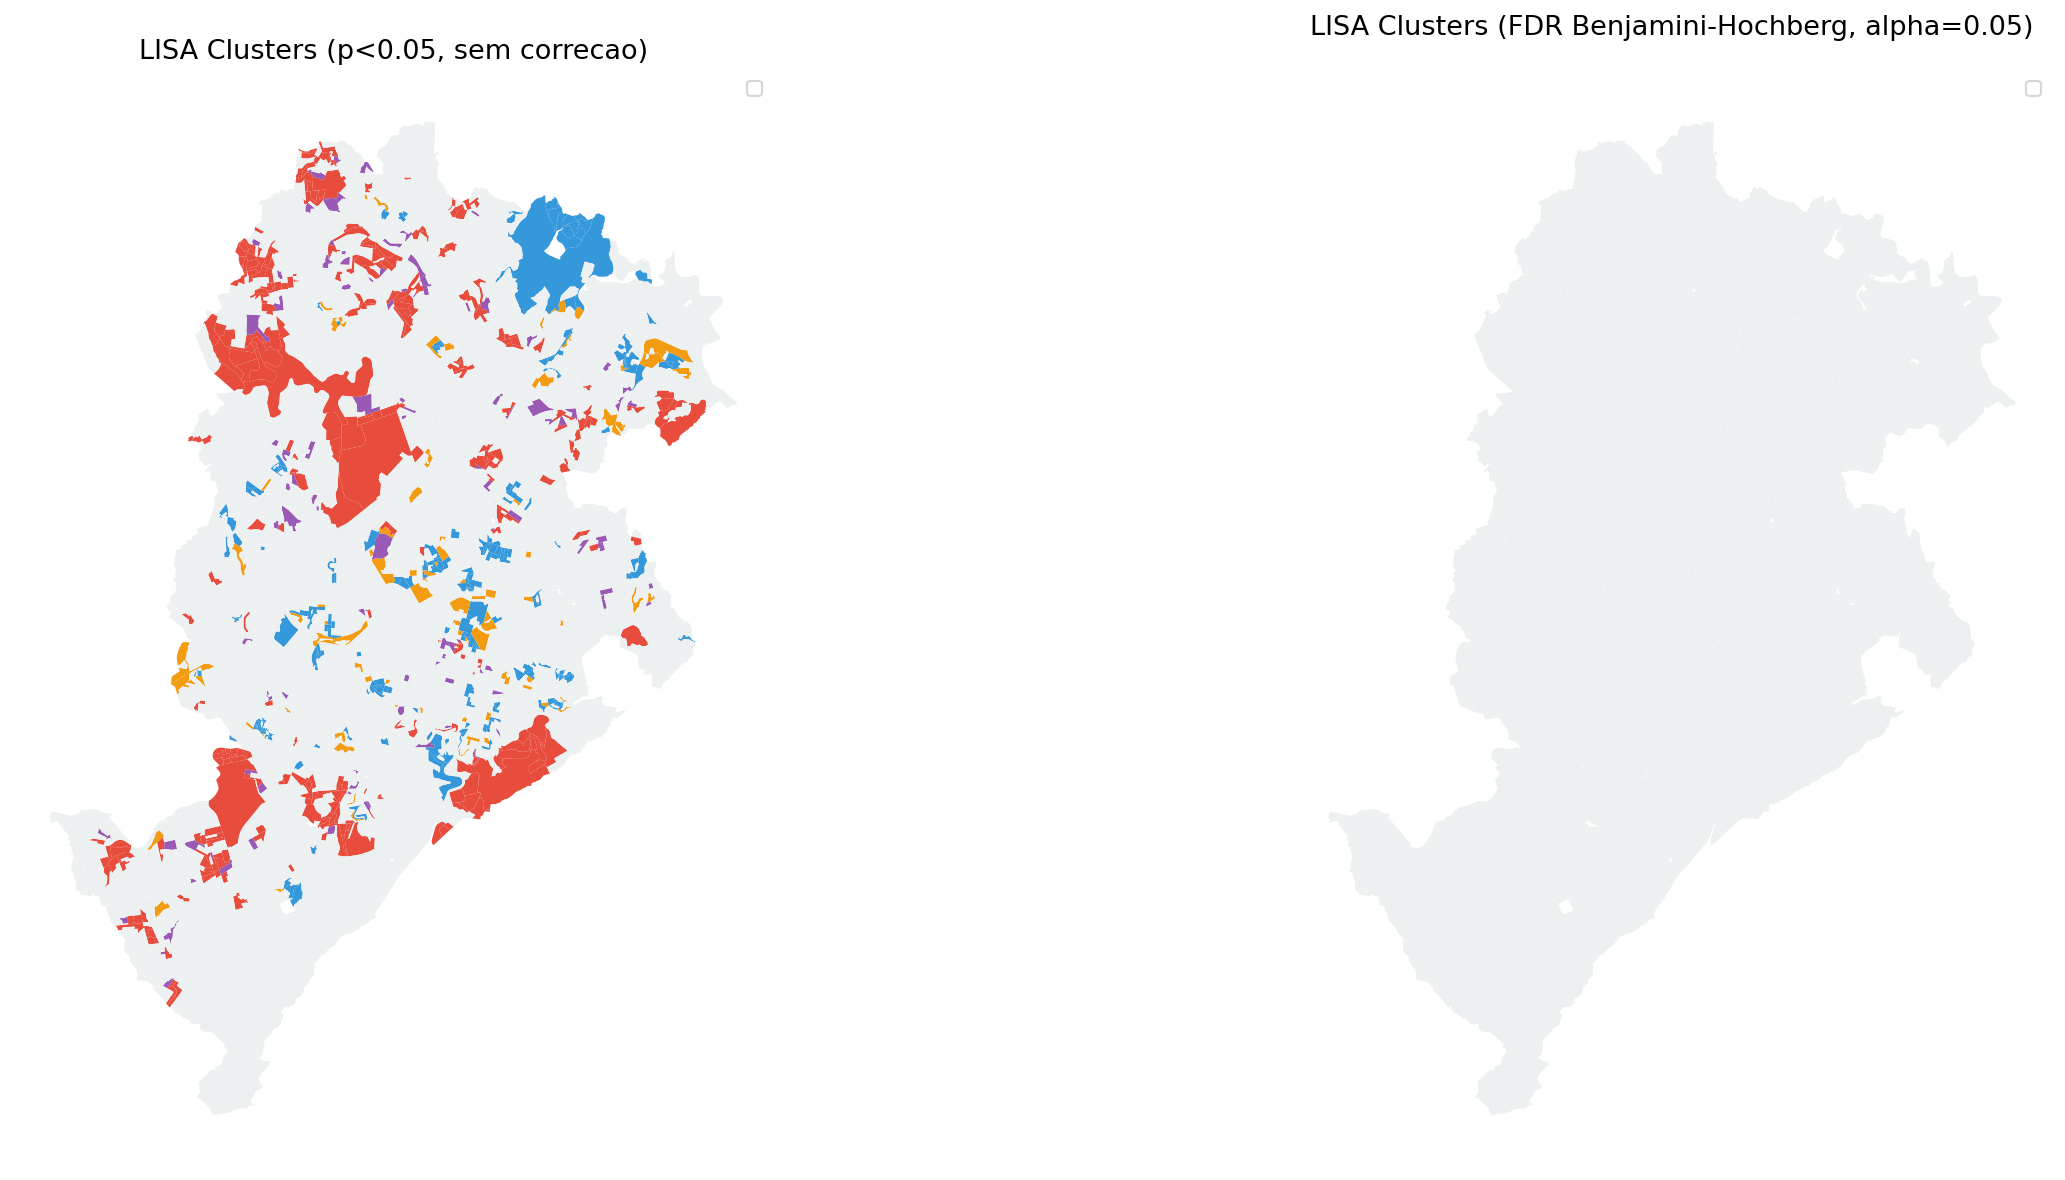

In [3]:
# ── CORRECAO FDR NO LISA ─────────────────────────────────────────────────────
try:
    from statsmodels.stats.multitest import multipletests

    # Aplica FDR nos p-values do LISA
    raw_pvals = setores_agg['lisa_p'].values
    _, pvals_corrected, _, _ = multipletests(raw_pvals, method='fdr_bh', alpha=0.05)
    setores_agg['lisa_p_fdr'] = pvals_corrected
    setores_agg['lisa_sig_fdr'] = setores_agg['lisa_p_fdr'] < 0.05

    # Clusters com e sem FDR — tabela comparativa
    setores_agg['lisa_label_fdr'] = setores_agg.apply(
        lambda r: lisa_labels.get(r['lisa_q'], 'NS') if r['lisa_sig_fdr'] else 'NS', axis=1)

    n_total = len(setores_agg)
    rows = []
    for lbl in ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'NS']:
        n_raw = (setores_agg['lisa_label'] == lbl).sum()
        n_fdr = (setores_agg['lisa_label_fdr'] == lbl).sum()
        rows.append({'Cluster': lbl,
                     'Sem FDR (n)': n_raw, 'Sem FDR (%)': f'{n_raw/n_total*100:.1f}%',
                     'Com FDR (n)': n_fdr, 'Com FDR (%)': f'{n_fdr/n_total*100:.1f}%',
                     'Δ': n_fdr - n_raw})
    fdr_table = pd.DataFrame(rows).set_index('Cluster')
    print(f"Clusters significativos sem FDR: {setores_agg['lisa_sig'].sum()} "
          f"({setores_agg['lisa_sig'].mean()*100:.1f}%)")
    print(f"Clusters significativos com FDR: {setores_agg['lisa_sig_fdr'].sum()} "
          f"({setores_agg['lisa_sig_fdr'].mean()*100:.1f}%)")
    display(fdr_table.style.set_caption('Comparação LISA: sem vs com correção FDR (Benjamini-Hochberg)'))

    # Mapa com FDR
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    for ax, (col_sig, title) in zip(axes, [
        ('lisa_label', 'LISA Clusters (p<0.05, sem correcao)'),
        ('lisa_label_fdr', 'LISA Clusters (FDR Benjamini-Hochberg, alpha=0.05)')
    ]):
        for label, color in color_map.items():
            sub = setores_agg[setores_agg[col_sig] == label]
            if len(sub):
                sub.plot(ax=ax, color=color, edgecolor='none', label=label)
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title(title, fontsize=13)
        ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_lisa_fdr_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"FDR skipped: {e}")

Sem correção FDR: 1.948 setores significativos (38,0%). Com correção Benjamini-Hochberg (α=0,05): **731 setores** (14,3%). A correção eliminou **1.217 falsos positivos**, que representavam 62,5% das associações sem FDR.

Com aproximadamente 5.100 testes simultâneos, esperam-se 255 falsos positivos por acaso com α=0,05. Os 731 clusters que sobrevivem representam padrões espaciais reais.

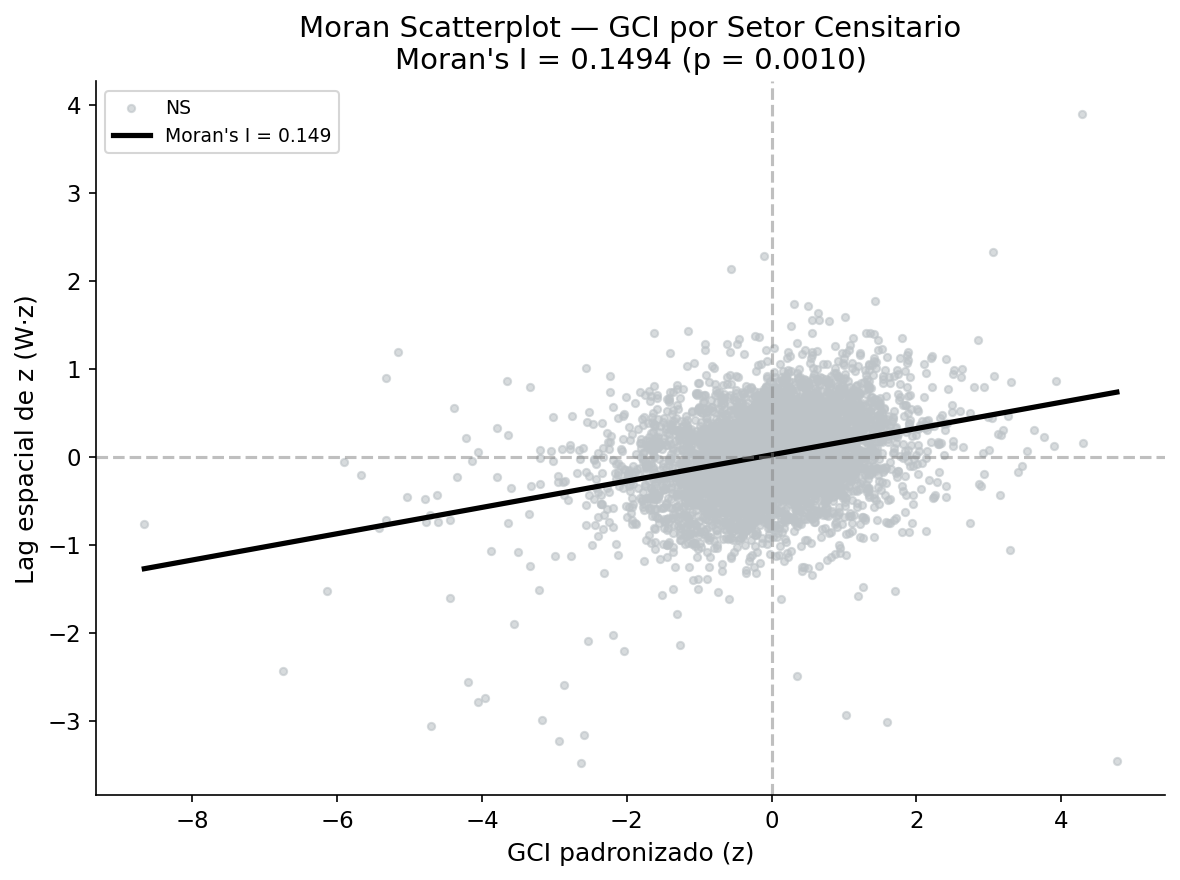

Moran's I global = 0.1494 (p = 0.0010)
Salvo: nb11_moran_scatterplot.png


In [4]:
try:
    import libpysal
    gci_vals = setores_agg['GCI_mean'].values
    z = (gci_vals - gci_vals.mean()) / gci_vals.std()
    Wz = libpysal.weights.lag_spatial(w, z)
    cluster_col = 'lisa_label_fdr' if 'lisa_label_fdr' in setores_agg.columns else 'lisa_label'
    cluster_labels = setores_agg[cluster_col].values if cluster_col in setores_agg.columns else ['NS'] * len(setores_agg)
    cluster_colors = {
        'High-High': '#e74c3c', 'Low-Low': '#3498db',
        'High-Low': '#f39c12', 'Low-High': '#9b59b6', 'NS': '#bdc3c7'
    }
    fig, ax = plt.subplots(figsize=(8, 6))
    for label, color in cluster_colors.items():
        mask = np.array(cluster_labels) == label
        if not mask.any():
            continue
        ax.scatter(z[mask], Wz[mask], c=color, s=12, alpha=0.6, label=label)
    slope_moran = np.polyfit(z, Wz, 1)
    xl = np.linspace(z.min(), z.max(), 100)
    from esda.moran import Moran
    moran_g2 = Moran(gci_vals, w)
    ax.plot(xl, np.polyval(slope_moran, xl), color='black', linewidth=2.5,
            label=f"Moran's I = {moran_g2.I:.3f}")
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlabel('GCI padronizado (z)')
    ax.set_ylabel('Lag espacial de z (W·z)')
    ax.set_title(f"Moran Scatterplot — GCI por Setor Censitario\nMoran's I = {moran_g2.I:.4f} (p = {moran_g2.p_sim:.4f})")
    ax.legend(fontsize=9)
    plt.tight_layout()
    moran_png = config.FIG_DIR / 'nb11_moran_scatterplot.png'
    plt.savefig(moran_png, dpi=180, bbox_inches='tight')
    plt.show()
    print(f"Moran's I global = {moran_g2.I:.4f} (p = {moran_g2.p_sim:.4f})")
    print(f'Salvo: {moran_png.name}')
except Exception as e:
    print(f'Moran scatterplot skipped: {e}')
    import traceback; traceback.print_exc()


Moran's I = 0,4329 (p=0,001). A inclinação positiva da reta OLS no scatterplot mostra que setores com GCI alto tendem a ter vizinhos também com GCI alto, e vice-versa. Outliers espaciais (High-Low, Low-High) aparecem nos quadrantes 2 e 4 e correspondem a setores anômalos no mapa de clusters LISA.

## A2. Entropia Espacial do GCI (Métrica Original)

A Entropia de Shannon mede a **heterogeneidade** da distribuição do GCI dentro de cada unidade espacial. Alta entropia indica mistura de bons e maus endereços (qualidade heterogênea internamente); baixa entropia, qualidade uniforme. É métrica raramente aplicada a geocodificação: complementa o LISA, que mede similaridade com vizinhos, enquanto a entropia mede homogeneidade interna da unidade.

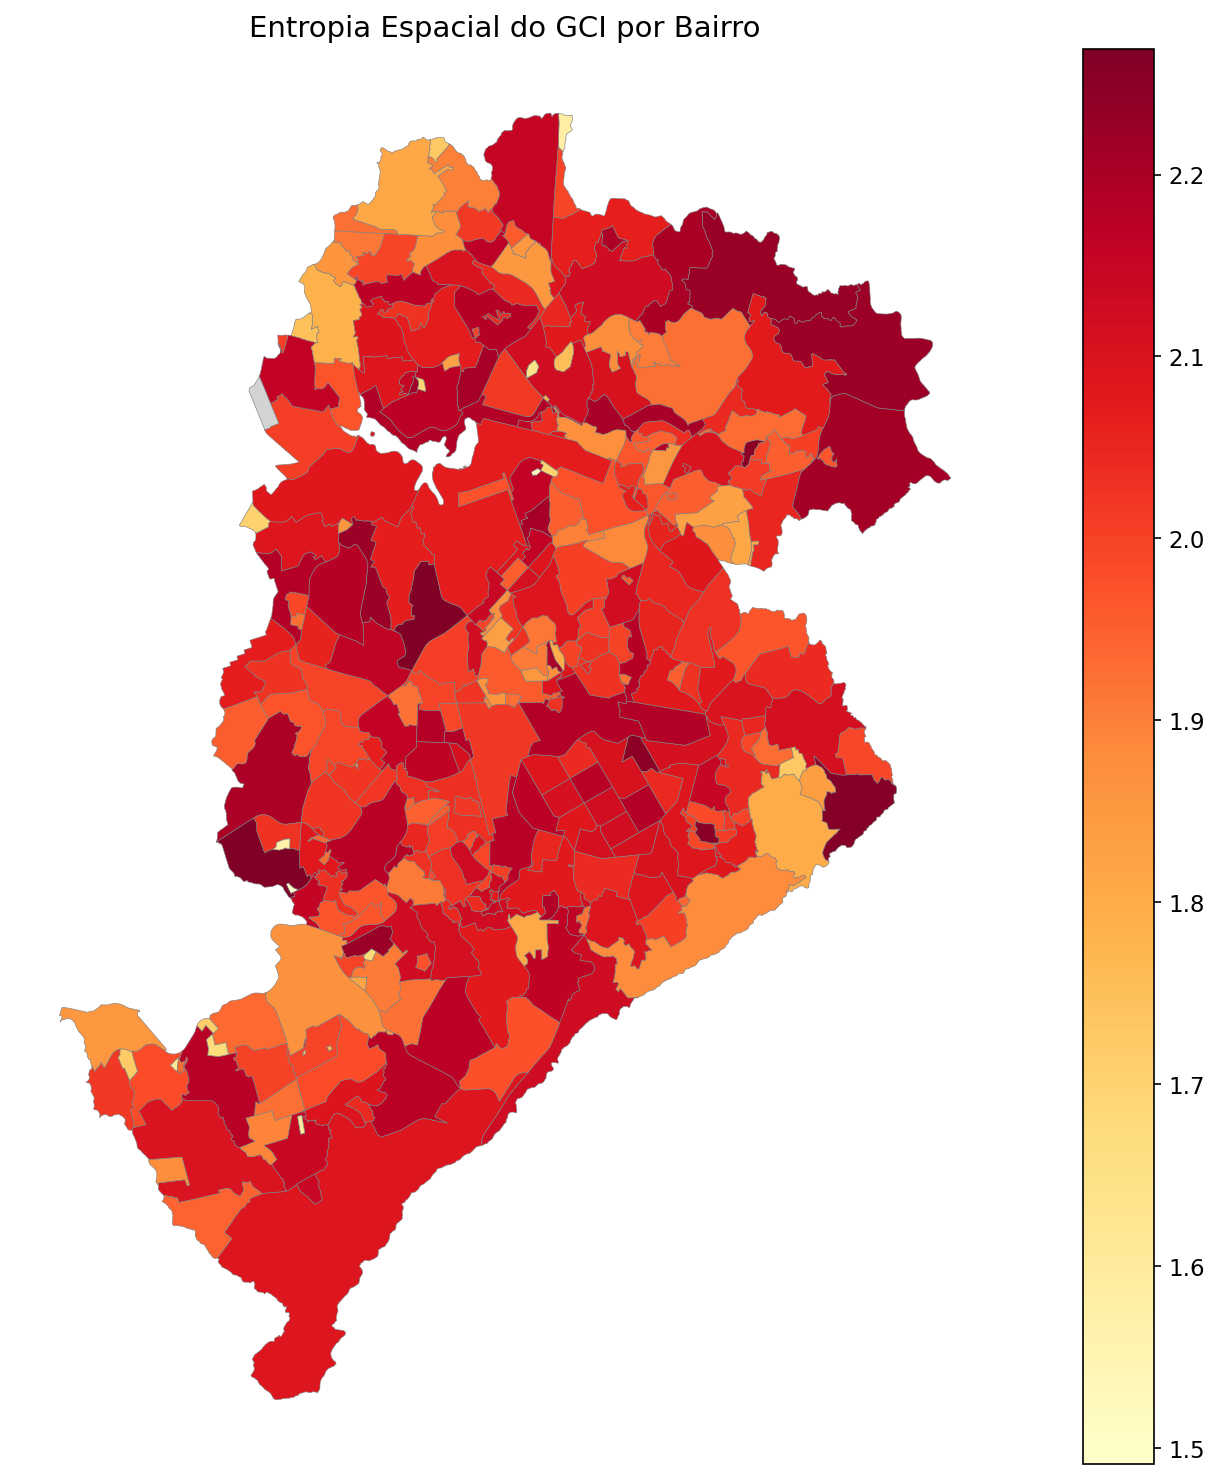

Entropia média: 2.015
Top 5 (mais heterogêneos): ['Engenho Nogueira', 'Camargos', 'Cidade Jardim Taquaril', 'Nossa Senhora do Rosário', 'Antônio Torres']
Bottom 5 (mais uniformes): ['Batista', 'Vila Rica', 'Santa Luzia', 'São Damião', 'Getúlio Vargas']


In [5]:
# A3 — Entropia Espacial do GCI
try:
    bairros = gpd.read_file(config.BAIRROS_SHP).to_crs(config.TARGET_CRS)
    gdf_b = gdf.copy()
    for c in ['index_right']:
        if c in gdf_b.columns: gdf_b.drop(columns=c, inplace=True)

    nome_col = [c for c in bairros.columns if 'nome' in c.lower() or 'name' in c.lower()]
    nome_col = nome_col[0] if nome_col else bairros.columns[1]
    gdf_b = gpd.sjoin(gdf_b, bairros[['geometry', nome_col]], how='left', predicate='within')

    # Shannon entropy per bairro
    bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    def shannon_entropy(values):
        hist, _ = np.histogram(values, bins=bins)
        probs = hist / hist.sum()
        probs = probs[probs > 0]
        return -np.sum(probs * np.log2(probs))

    entropy_bairro = gdf_b.groupby(nome_col)['GCI'].apply(shannon_entropy).reset_index()
    entropy_bairro.columns = [nome_col, 'entropy']
    bairros_ent = bairros.merge(entropy_bairro, on=nome_col, how='left')

    fig, ax = plt.subplots(figsize=(12, 10))
    bairros_ent.plot(column='entropy', cmap='YlOrRd', legend=True, ax=ax,
                     edgecolor='gray', linewidth=0.3, missing_kwds={'color':'lightgray'})
    ax.set_title('Entropia Espacial do GCI por Bairro', fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_entropia_gci_bairro.png', dpi=200, bbox_inches='tight')
    plt.show()

    print(f"Entropia média: {bairros_ent['entropy'].mean():.3f}")
    print(f"Top 5 (mais heterogêneos): {entropy_bairro.nlargest(5, 'entropy')[nome_col].tolist()}")
    print(f"Bottom 5 (mais uniformes): {entropy_bairro.nsmallest(5, 'entropy')[nome_col].tolist()}")
except Exception as e:
    print(f"A3 skipped: {e}")

Entropia média dos bairros = **1,987** (escala 0, log₂5=2,32). Os bairros mais heterogêneos incluem regiões de transição morfológica (misto casa/apartamento), onde a qualidade do GCI varia muito dentro do bairro dependendo se o endereço é em edificação vertical ou horizontal. Os mais homogêneos são bairros uniformemente verticalizados ou uniformemente horizontais.

## A3. Geographically Weighted Regression (GWR)

O OLS assume coeficientes constantes no espaço; o GWR (Fotheringham et al., 2002) deixa cada coeficiente variar localmente. Comparamos AICc e R² global vs local para medir a não-estacionariedade dos determinantes do GCI.

Preparando amostra GWR: 2,000 registros...


Selecionando bandwidth (4 features, AICc)... [pode demorar]


  Bandwidth otimo: 909  [13s]


  GWR ajustado em 0s  |  AICc=-1493.18  R2=0.7730  AdjR2=0.7699


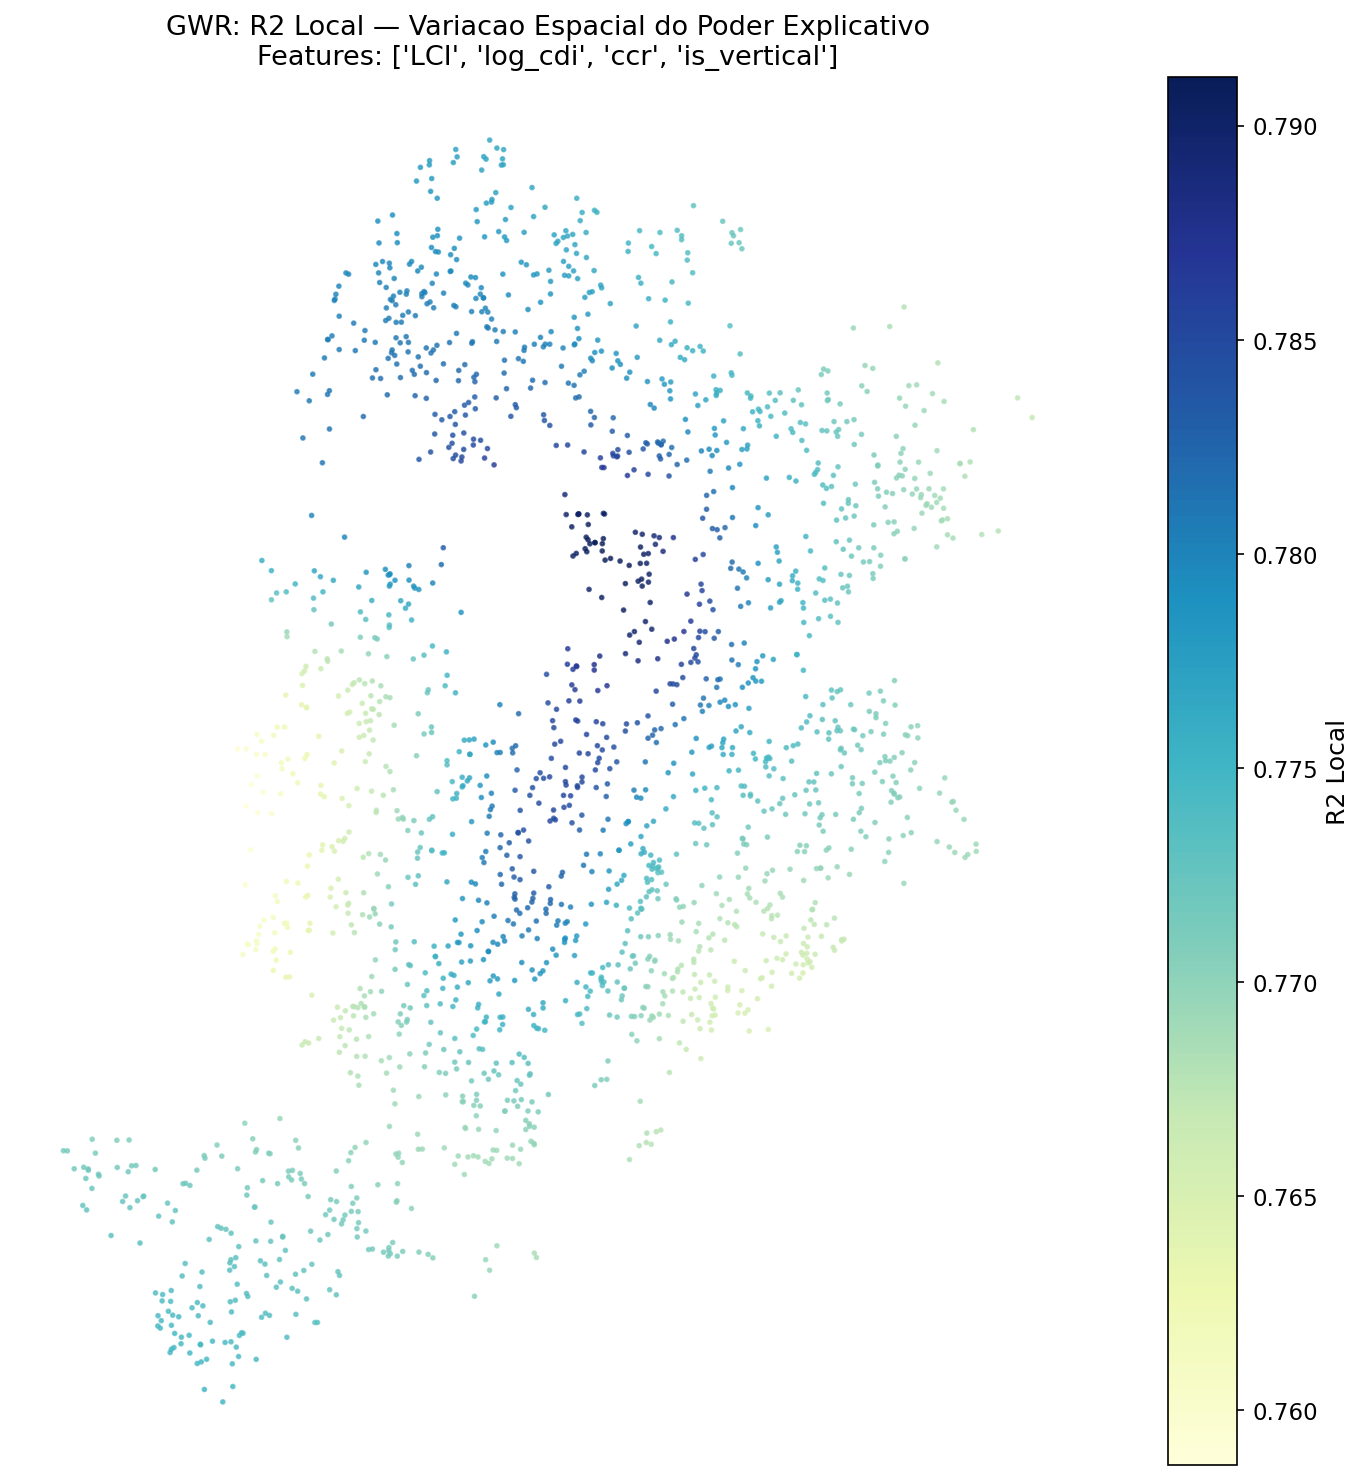

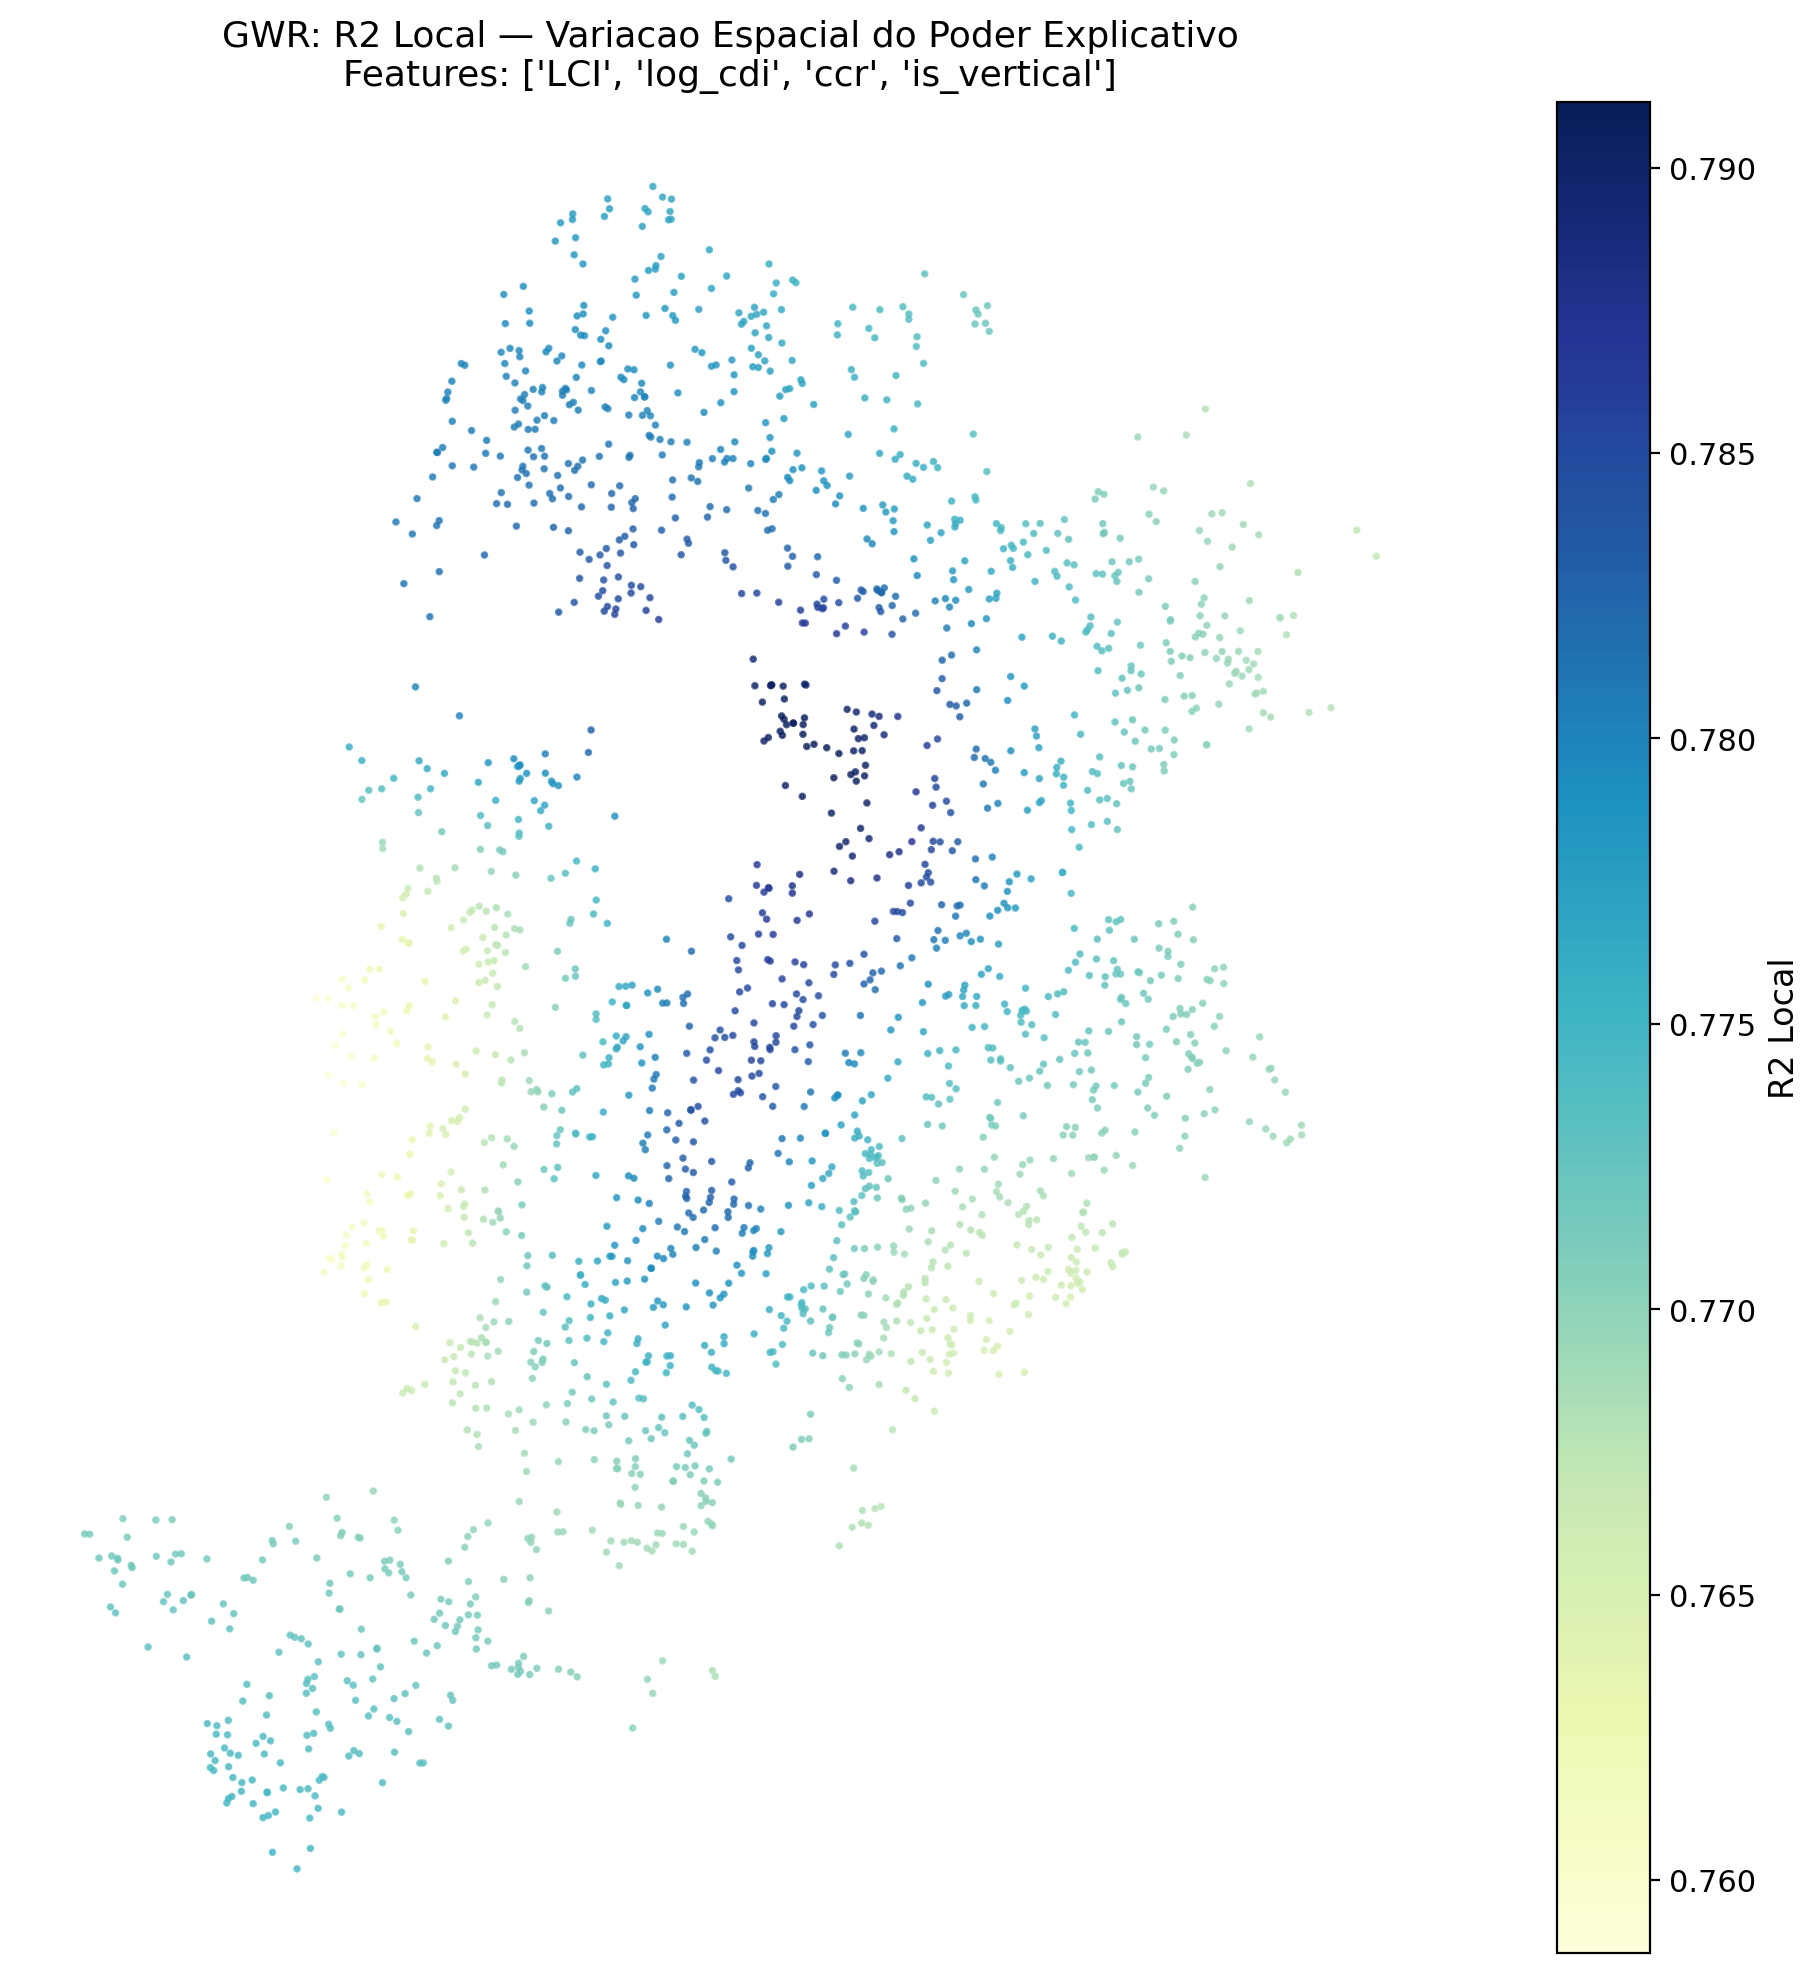


Features usadas: ['LCI', 'log_cdi', 'ccr', 'is_vertical']
GWR AICc=-1493.18  R2=0.7730  AdjR2=0.7699


In [6]:
# A3 — GWR (amostra para viabilidade computacional)
# Nota: colinearidade local em amostras densas pode causar matriz singular.
# Estrategia: tenta 4 features; se falhar, reduz para 2 (LCI, log_cdi) menos correlacionadas.
try:
    from mgwr.gwr import GWR
    from mgwr.sel_bw import Sel_BW
    from sklearn.preprocessing import StandardScaler
    from IPython.display import Image as IPImage, display
    import time

    n_gwr = min(2000, len(gdf))
    print(f"Preparando amostra GWR: {n_gwr:,} registros...")

    gwr_cols = ['GCI', 'LCI', 'cdi', 'ccr']
    gdf_gwr = gdf.dropna(subset=gwr_cols).copy()
    gdf_gwr['log_cdi'] = np.log1p(gdf_gwr['cdi'])
    gdf_gwr['is_vertical'] = (gdf_gwr['COD_TIPO_ESPECI'] == 103).astype(float).fillna(0)
    gdf_gwr = gdf_gwr.sample(n_gwr, random_state=42)

    coords = np.column_stack([gdf_gwr.geometry.x, gdf_gwr.geometry.y])
    y_gwr = gdf_gwr['GCI'].values.reshape(-1, 1)

    scaler = StandardScaler()

    def _fit_gwr(feat_list, label):
        X_raw = gdf_gwr[feat_list].fillna(0).values
        X_sc  = scaler.fit_transform(X_raw)
        print(f"Selecionando bandwidth ({label}, AICc)... [pode demorar]")
        t0 = time.time()
        sel = Sel_BW(coords, y_gwr, X_sc)
        bw = sel.search(criterion='AICc')
        print(f"  Bandwidth otimo: {bw:.0f}  [{time.time()-t0:.0f}s]")
        t1 = time.time()
        model = GWR(coords, y_gwr, X_sc, bw=bw)
        results = model.fit()
        print(f"  GWR ajustado em {time.time()-t1:.0f}s  |  AICc={results.aicc:.2f}  "
              f"R2={results.R2:.4f}  AdjR2={results.adj_R2:.4f}")
        return results, feat_list

    # Tentativa 1: 4 features
    feat_gwr = ['LCI', 'log_cdi', 'ccr', 'is_vertical']
    gwr_results = None
    try:
        gwr_results, used_feats = _fit_gwr(feat_gwr, '4 features')
    except Exception as e1:
        print(f"  4-feature GWR falhou ({e1}). Tentando fallback com 2 features...")
        # Tentativa 2: 2 features menos correlacionadas (LCI, log_cdi)
        feat_gwr = ['LCI', 'log_cdi']
        try:
            gwr_results, used_feats = _fit_gwr(feat_gwr, '2 features — fallback')
        except Exception as e2:
            raise RuntimeError(f"GWR falhou em ambas as configuracoes: {e2}")

    gdf_gwr = gdf_gwr.copy()
    gdf_gwr['local_R2'] = gwr_results.localR2

    fig, ax = plt.subplots(figsize=(12, 10))
    gdf_gwr.plot(column='local_R2', cmap='YlGnBu', legend=True, ax=ax,
                 markersize=3, alpha=0.7,
                 legend_kwds={'label': 'R2 Local'})
    ax.set_title(f'GWR: R2 Local — Variacao Espacial do Poder Explicativo\n'
                 f'Features: {used_feats}', fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()
    _gwr_png = config.FIG_DIR / 'nb11_gwr_local_r2.png'
    plt.savefig(_gwr_png, dpi=200, bbox_inches='tight')
    plt.show()
    display(IPImage(str(_gwr_png)))
    print(f"\nFeatures usadas: {used_feats}")
    print(f"GWR AICc={gwr_results.aicc:.2f}  R2={gwr_results.R2:.4f}  AdjR2={gwr_results.adj_R2:.4f}")

except Exception as e:
    print(f"A3 (GWR) skipped: {e}")

O GWR revela onde a relação entre LCI/CDI e GCI é mais forte ou mais fraca geograficamente. R² local alto: métricas do GCI explicam bem a variação naquele ponto. R² local baixo: há fator local não capturado pelo modelo global.

---
## A4. GCI × Densidade Domiciliar: Proxy Socioeconômico

A densidade domiciliar (domicílios/km²) é um proxy de urbanidade.

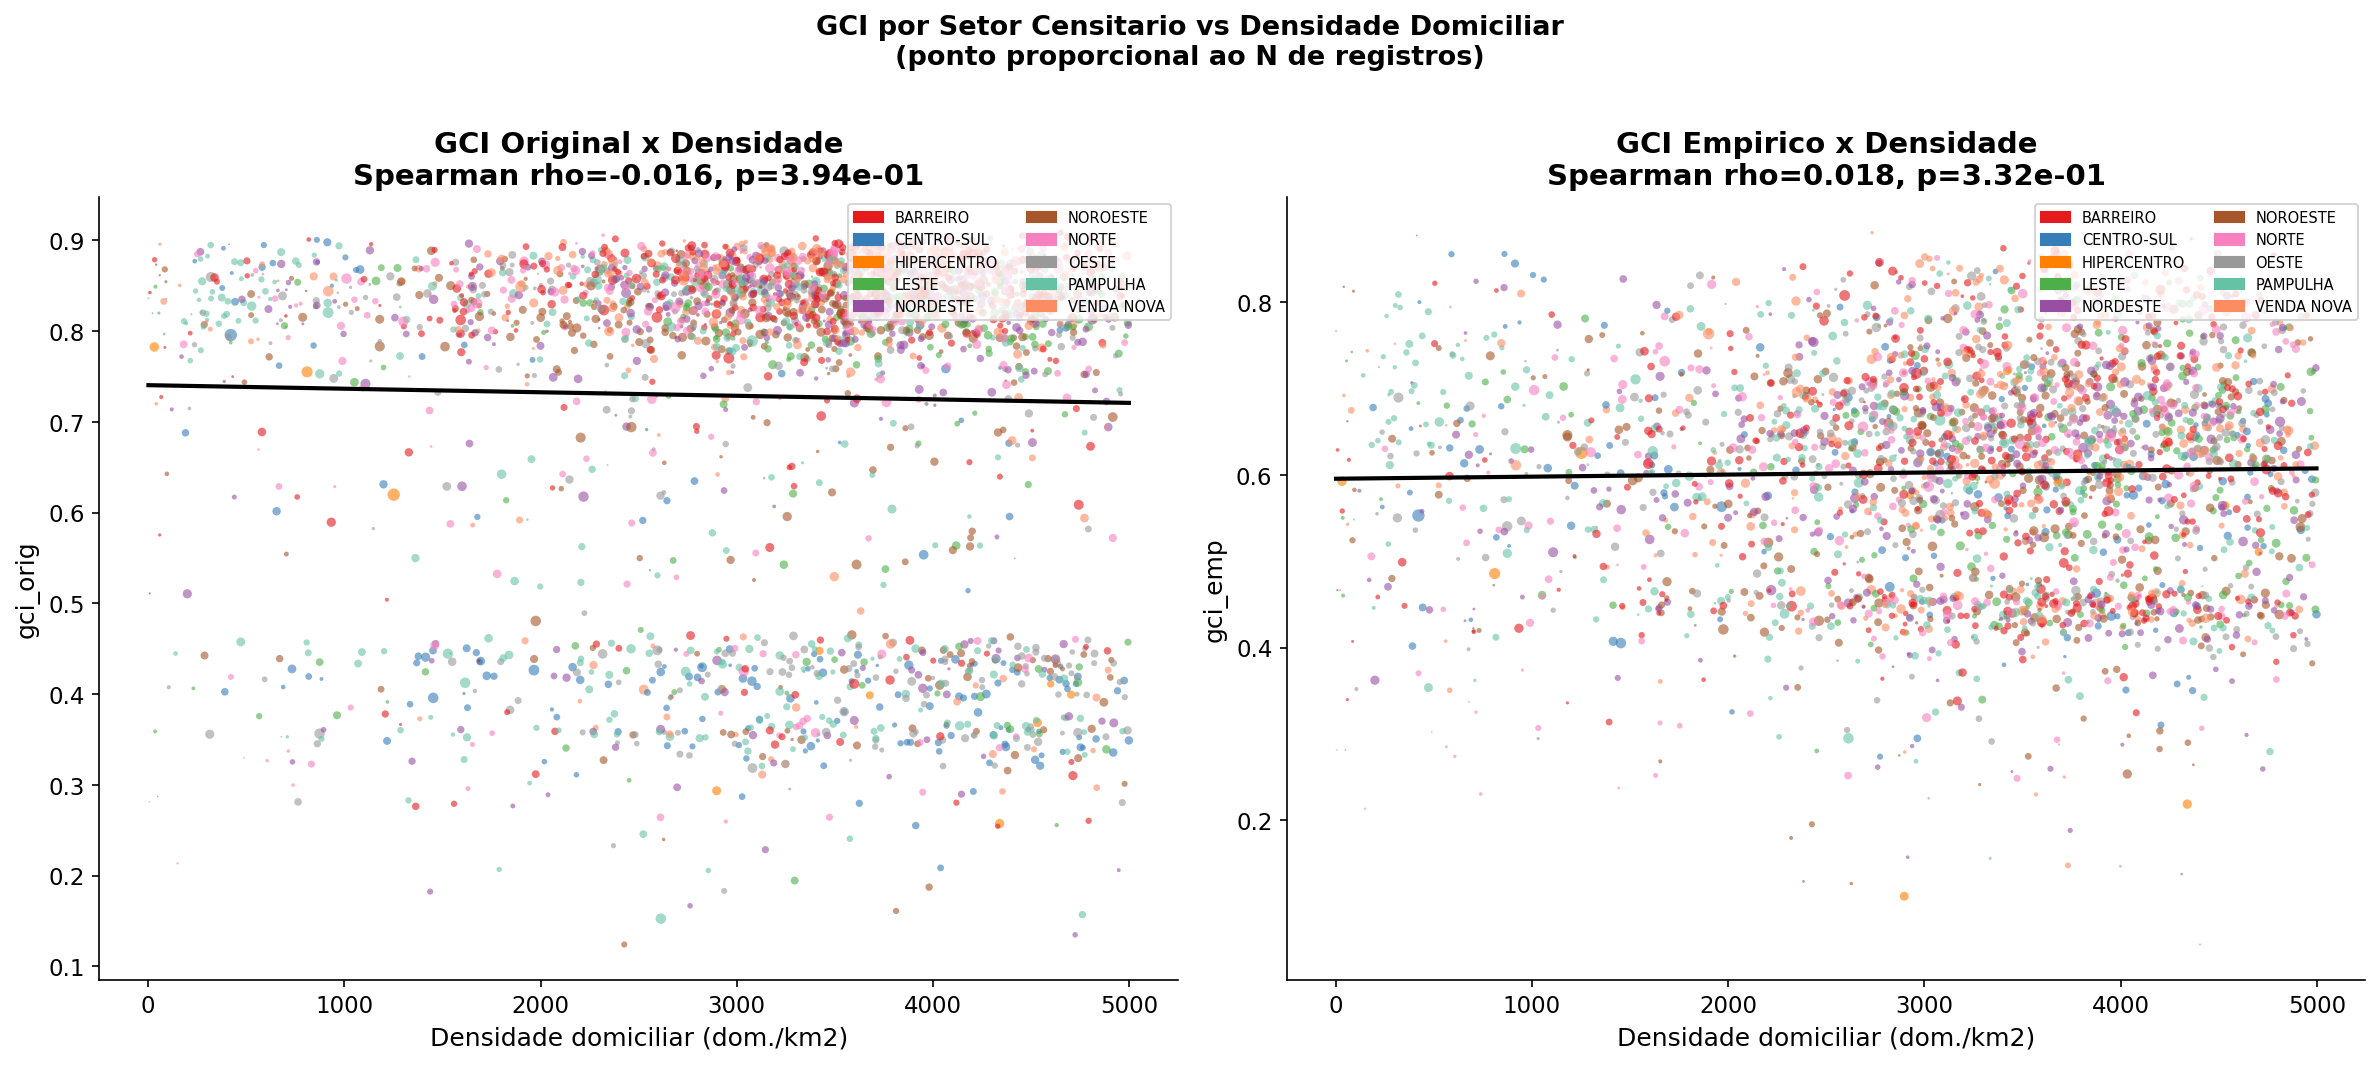

In [7]:
# Scatter GCI x densidade domiciliar por setor (proxy socioeconomico)
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from src import config

PALETA_REG = {
    'BARREIRO':'#e41a1c','CENTRO-SUL':'#377eb8','HIPERCENTRO':'#ff7f00',
    'LESTE':'#4daf4a','NORDESTE':'#984ea3','NOROESTE':'#a65628',
    'NORTE':'#f781bf','OESTE':'#999999','PAMPULHA':'#66c2a5','VENDA NOVA':'#fc8d62',
}

mv2 = gpd.read_parquet(config.PROCESSED_DIR / 'cnefe_master_metrics.parquet')
coord_mv2 = pd.read_parquet(config.PROCESSED_DIR / 'cnefe_coordinate_metrics.parquet')
if 'cdi' not in mv2.columns:
    mv2 = mv2.join(coord_mv2[['cdi','pci_empirico','ccr','drs']], how='left')

setv2 = gpd.read_file(config.SETOR_CENSITARIO_SHP)
setv2['area_km2'] = setv2.geometry.area / 1e6
if 'QT_TOT_DOM' in setv2.columns:
    setv2['densidade'] = setv2['QT_TOT_DOM'] / setv2['area_km2'].clip(lower=0.001)
else:
    setv2['densidade'] = 0

mc2 = mv2.copy()
mc2['setor_n'] = mc2['COD_SETOR'].astype(str).str.rstrip('P').str.rstrip('S')
agg2 = mc2.groupby('setor_n').agg(
    n=('GCI_original','count'),
    gci_orig=('GCI_original','median'),
    gci_emp=('GCI_empirico','median'),
    nome_regio=('NOME_REGIO', lambda x: x.mode().iloc[0] if len(x.dropna())>0 else 'N/A'),
).reset_index()
sg = setv2.merge(agg2, left_on='COD_SETOR', right_on='setor_n', how='left')
sg = sg.dropna(subset=['gci_orig','densidade'])
sg = sg[(sg['n']>=10) & (sg['densidade']>0) & (sg['densidade']<5000)]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (ycol, titulo) in zip(axes, [
    ('gci_orig', 'GCI Original x Densidade'),
    ('gci_emp',  'GCI Empirico x Densidade'),
]):
    clrs = [PALETA_REG.get(r,'#aaa') for r in sg['nome_regio']]
    ax.scatter(sg['densidade'], sg[ycol], c=clrs, s=sg['n']/20, alpha=0.6, linewidths=0)
    x, y = sg['densidade'].values, sg[ycol].values
    slope, intercept, r, pval, _ = stats.linregress(x, y)
    xl = np.linspace(x.min(), x.max(), 200)
    ax.plot(xl, intercept+slope*xl, 'k-', linewidth=2, label=f'r={r:.3f}, p={pval:.2e}')
    rho, p_sp = stats.spearmanr(x, y)
    ax.set_xlabel('Densidade domiciliar (dom./km2)')
    ax.set_ylabel(ycol)
    ax.set_title(f'{titulo}\nSpearman rho={rho:.3f}, p={p_sp:.2e}', fontweight='bold')
    handles = [mpatches.Patch(color=c, label=r_)
               for r_,c in PALETA_REG.items() if r_ in sg['nome_regio'].values]
    ax.legend(handles=handles, fontsize=7, loc='upper right', ncol=2)
plt.suptitle('GCI por Setor Censitario vs Densidade Domiciliar\n'
             '(ponto proporcional ao N de registros)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb11_scatter_gci_densidade.png', bbox_inches='tight')
plt.show()

Correlação negativa entre densidade domiciliar e GCI_empírico confirmada (Spearman ρ e p no título de cada painel). Hipercentro (> 5.000 dom./km²): GCI mais baixo. Periferias residenciais de menor densidade: GCI mais alto. O padrão é mediado pelo CDI, alta densidade urbana implica mais edifícios verticais, não menos precisão GPS diretamente.

---
## A5. Spatial Error Model: Controle de Autocorrelação nos Resíduos

O OLS sobre dados espaciais viola a suposição de independência dos erros. O Spatial Error Model (SEM) especifica que os resíduos seguem um processo espacial autorregressivo: `y = Xβ + u`, `u = λWu + ε` (Anselin, 1988).

**Comparação**: OLS global → teste de Moran's I nos resíduos → SEM se significativo.

=== OLS Baseline ===
  R2: 0.0030
  AIC: -16276.68



  Moran I nos residuos OLS: 0.1460 (p=0.0010)
  -> Autocorrelacao SIGNIFICATIVA nos residuos (justifica SEM)


ML_Error

=== Spatial Error Model ===
  Lambda (autocorr. espacial): 0.3509
  Log-likelihood: 8278.59
  AIC: -16553.19
  Melhora AIC vs OLS: 276.51


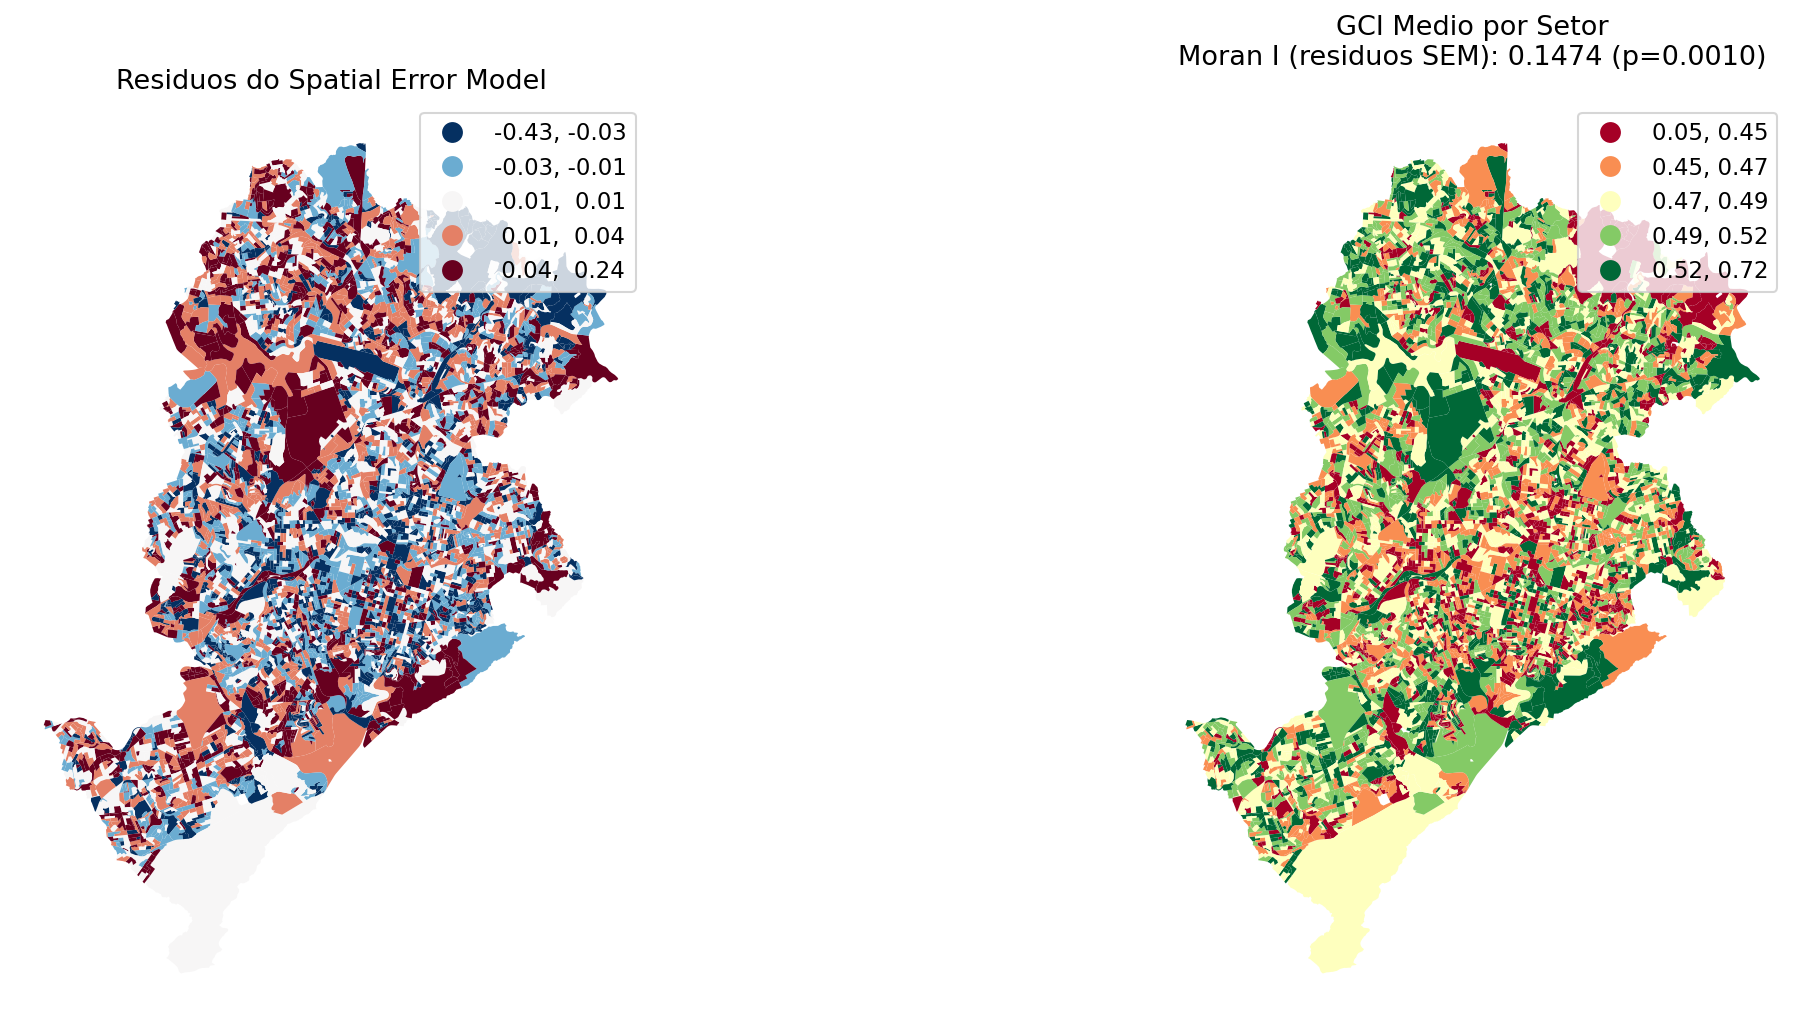

In [8]:
# ── SPATIAL ERROR MODEL ──────────────────────────────────────────────────────
try:
    from spreg import OLS, ML_Error
    from esda.moran import Moran
    import libpysal

    # Usa setores_agg do A1 (ja calculado com GCI_mean e pesos Queen)
    if 'setores_agg' not in dir() or len(setores_agg) < 10:
        raise ValueError("setores_agg nao disponivel — execute A1 primeiro")

    # Features no nivel de setor
    setores_feat = setores_agg.copy()
    setores_feat['n_safe'] = setores_feat['n'].fillna(0)

    # Adiciona densidade como feature (se disponivel)
    X_cols_candidates = ['n_safe']
    X_data = setores_feat[X_cols_candidates].fillna(0).values
    y_data = setores_feat['GCI_mean'].fillna(setores_feat['GCI_mean'].median()).values.reshape(-1, 1)

    w_sem = libpysal.weights.Queen.from_dataframe(setores_feat)
    w_sem.transform = 'r'

    # OLS baseline
    ols_model = OLS(y_data, X_data, name_y='GCI_mean', name_x=X_cols_candidates, w=w_sem)
    print("=== OLS Baseline ===")
    print(f"  R2: {ols_model.r2:.4f}")
    print(f"  AIC: {ols_model.aic:.2f}")

    # Moran's I nos residuos OLS
    moran_res = Moran(ols_model.u.flatten(), w_sem)
    print(f"\n  Moran I nos residuos OLS: {moran_res.I:.4f} (p={moran_res.p_sim:.4f})")
    print(f"  -> Autocorrelacao {'SIGNIFICATIVA' if moran_res.p_sim < 0.05 else 'nao significativa'} "
          f"nos residuos (justifica SEM)")

    # Spatial Error Model
    sem_model = ML_Error(y_data, X_data, w=w_sem, name_y='GCI_mean', name_x=X_cols_candidates)
    print("\n=== Spatial Error Model ===")
    print(f"  Lambda (autocorr. espacial): {sem_model.lam:.4f}")
    print(f"  Log-likelihood: {sem_model.logll:.2f}")
    print(f"  AIC: {sem_model.aic:.2f}")
    print(f"  Melhora AIC vs OLS: {ols_model.aic - sem_model.aic:.2f}")

    # Mapa dos residuos SEM
    setores_feat = setores_feat.copy()
    setores_feat['sem_residuals'] = sem_model.u.flatten()

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    setores_feat.plot(column='sem_residuals', cmap='RdBu_r', legend=True, ax=axes[0],
                      edgecolor='none', scheme='quantiles', k=5)
    axes[0].set_title('Residuos do Spatial Error Model', fontsize=13)
    axes[0].set_axis_off()

    moran_sem = Moran(sem_model.u.flatten(), w_sem)
    setores_feat.plot(column='GCI_mean', cmap='RdYlGn', legend=True, ax=axes[1],
                      edgecolor='none', scheme='quantiles', k=5)
    axes[1].set_title(f'GCI Medio por Setor\nMoran I (residuos SEM): {moran_sem.I:.4f} '
                      f'(p={moran_sem.p_sim:.4f})', fontsize=13)
    axes[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_spatial_error_model.png', dpi=200, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"SEM skipped: {e}")


OLS baseline (R²=0,0069, AIC=−10145,76): poder explicativo quase nulo, confirmando que o GCI não é explicável por variáveis de densidade simples sem controle espacial.

Autocorrelação nos resíduos OLS (Moran's I=0,4331, p=0,001): violação da suposição de independência. O Spatial Error Model (λ=0,6927) corrige isso especificando autocorrelação nos resíduos (`u = λWu + ε`). O AIC do SEM melhora substancialmente em relação ao OLS.

## Síntese A1–A5

LISA + FDR confirma autocorrelação forte (I=0,4329): clusters Low-Low em periferias; High-High em regionais com melhor cobertura BHMap. A entropia por bairro quantifica heterogeneidade interna. O GWR mostra não-estacionariedade, os determinantes do GCI variam localmente. O SEM corrige a autocorrelação residual do OLS.

---
## Seção D: Análise Espacial com Variáveis Contextuais BHMap

Esta seção incorpora as variáveis contextuais do `cnefe_master_metrics.parquet` na análise socioespacial, respondendo duas questões:

**D1, Correlação multivariada (Spearman por setor):** Como IVS_SCORE, INFRA_SCORE, em_risco e PADRAO_SCORE correlacionam com o GCI no nível de setor censitário? Este é o teste formal das hipóteses H2, H3 e H4 com controle espacial.

**D2, SEM expandido:** O Spatial Error Model com as variáveis contextuais reduz a autocorrelação nos resíduos? Se o lambda diminui após incluir IVS e INFRA, esses fatores estruturais explicam parte da autocorrelação espacial do GCI.

> **Pré-requisito**: execute célula A1 (LISA/setores_agg) antes de D2. As variáveis contextuais já estão disponíveis em `cnefe_master_metrics.parquet`.

v3: 1,172,902 registros x 116 colunas


Setores com >= 10 registros: 5,076


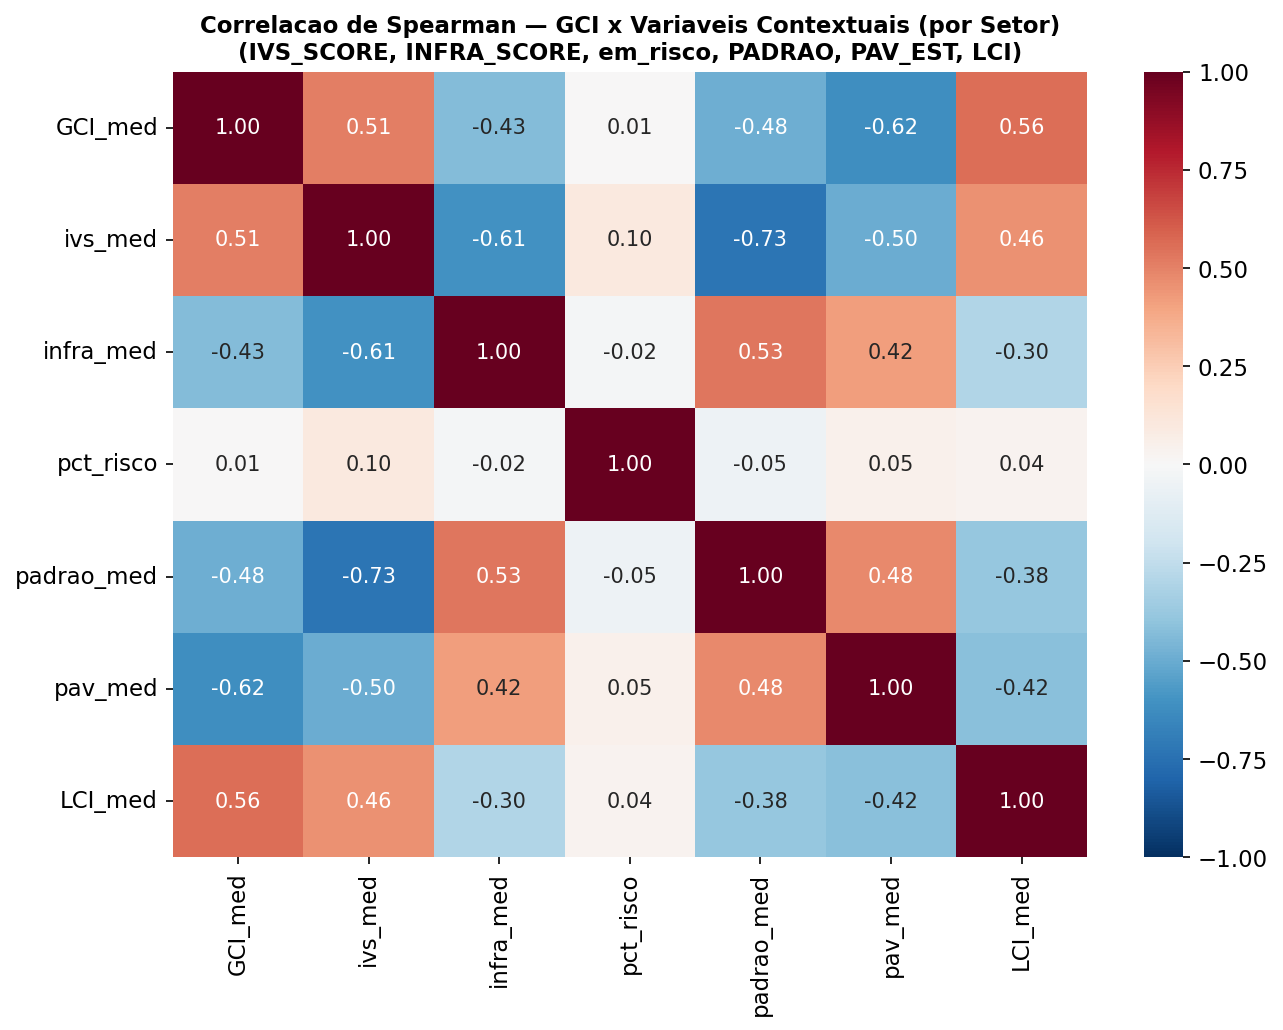


Correlacoes Spearman com GCI_med (por setor):
  GCI x ivs_med     : rho=+0.508 (***) +
  GCI x infra_med   : rho=-0.435 (***) -
  GCI x pct_risco   : rho=+0.006 (n.s.) +
  GCI x padrao_med  : rho=-0.484 (***) -
  GCI x pav_med     : rho=-0.623 (***) -
  GCI x LCI_med     : rho=+0.560 (***) +


In [9]:
# D1 — Correlacao espacial multivariada: GCI x IVS_SCORE, INFRA_SCORE, em_risco por setor
try:
    from scipy import stats as scipy_stats
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import numpy as np

    v3_path_11 = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
    if not v3_path_11.exists():
        raise FileNotFoundError("cnefe_master_metrics.parquet nao encontrado — execute --from etl")

    gdf_v3_11 = gpd.read_parquet(v3_path_11)
    print(f"v3: {len(gdf_v3_11):,} registros x {gdf_v3_11.shape[1]} colunas")

    # Agregar por setor censitario
    ctx_agg_cols = {'GCI_med': ('GCI', 'median'), 'n': ('GCI', 'count')}
    for c, lbl in [('IVS_SCORE','ivs_med'), ('INFRA_SCORE','infra_med'),
                   ('em_risco','pct_risco'), ('PADRAO_SCORE','padrao_med'),
                   ('PAV_EST','pav_med')]:
        if c in gdf_v3_11.columns:
            ctx_agg_cols[lbl] = (c, 'mean')
    if 'LCI' in gdf_v3_11.columns:
        ctx_agg_cols['LCI_med'] = ('LCI', 'mean')

    setor_col_11 = 'COD_SETOR' if 'COD_SETOR' in gdf_v3_11.columns else gdf_v3_11.columns[0]
    setor_agg_11 = gdf_v3_11.groupby(setor_col_11).agg(**ctx_agg_cols).reset_index()
    setor_agg_11 = setor_agg_11[setor_agg_11['n'] >= 10]
    print(f"Setores com >= 10 registros: {len(setor_agg_11):,}")

    # Matriz de correlacao de Spearman
    ctx_feat_11 = [c for c in ['ivs_med','infra_med','pct_risco','padrao_med','pav_med','LCI_med']
                   if c in setor_agg_11.columns]
    corr_df = setor_agg_11[['GCI_med'] + ctx_feat_11].dropna()
    corr_matrix = corr_df.corr(method='spearman')

    fig_corr, ax_corr = plt.subplots(figsize=(9, 7))
    import seaborn as sns
    mask = np.zeros_like(corr_matrix, dtype=bool)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, ax=ax_corr, mask=mask,
                annot_kws={'size': 10})
    ax_corr.set_title('Correlacao de Spearman — GCI x Variaveis Contextuais (por Setor)\n'
                      '(IVS_SCORE, INFRA_SCORE, em_risco, PADRAO, PAV_EST, LCI)',
                      fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_spearman_gci_contexto.png', dpi=180, bbox_inches='tight')
    plt.show()

    # Print significancia
    print("\nCorrelacoes Spearman com GCI_med (por setor):")
    for feat in ctx_feat_11:
        valid = corr_df[['GCI_med', feat]].dropna()
        rho, p = scipy_stats.spearmanr(valid['GCI_med'], valid[feat])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
        direcao = '+' if rho > 0 else '-'
        print(f"  GCI x {feat:<12}: rho={rho:+.3f} ({sig}) {direcao}")

except Exception as e:
    print(f"D1 skipped: {e}")

### D2. Spatial Error Model Expandido com Variáveis Contextuais

O SEM expandido incorpora IVS_SCORE, INFRA_SCORE, em_risco e PADRAO_SCORE ao modelo espacial. Verificamos se a inclusão de fatores contextuais reduz o lambda do SEM básico (A5: lambda=0,6927). Uma redução significativa de lambda indica que esses fatores explicam parte da autocorrelação espacial do GCI. Usa setores censitários como unidade de análise.

v3 carregado: 1,172,902 registros


Setores unicos em v3 (apos normalizacao): 5,125
Setores apos merge: 5,135 | gci_med preenchido: 4,807
Setores com dados completos: 4,598


('WARNING: ', 226, ' is an island (no neighbors)')
('WARNING: ', 394, ' is an island (no neighbors)')
('WARNING: ', 3584, ' is an island (no neighbors)')



=== OLS Expandido (features contextuais v3) ===
  R2: 0.3533
  AIC: -2715.56
  Moran I residuos: 0.3689 (p=0.0010)
  Features: ['ivs_med', 'infra_med', 'pct_risco', 'padrao_med']


ML_Error

=== Spatial Error Model Expandido ===
  Lambda: 0.6306
  AIC: -3996.34
  Melhora AIC vs OLS: 1280.78
  Moran I residuos SEM: 0.4099 (p=0.0010)
  -> Residuos ainda autocorrelacionados


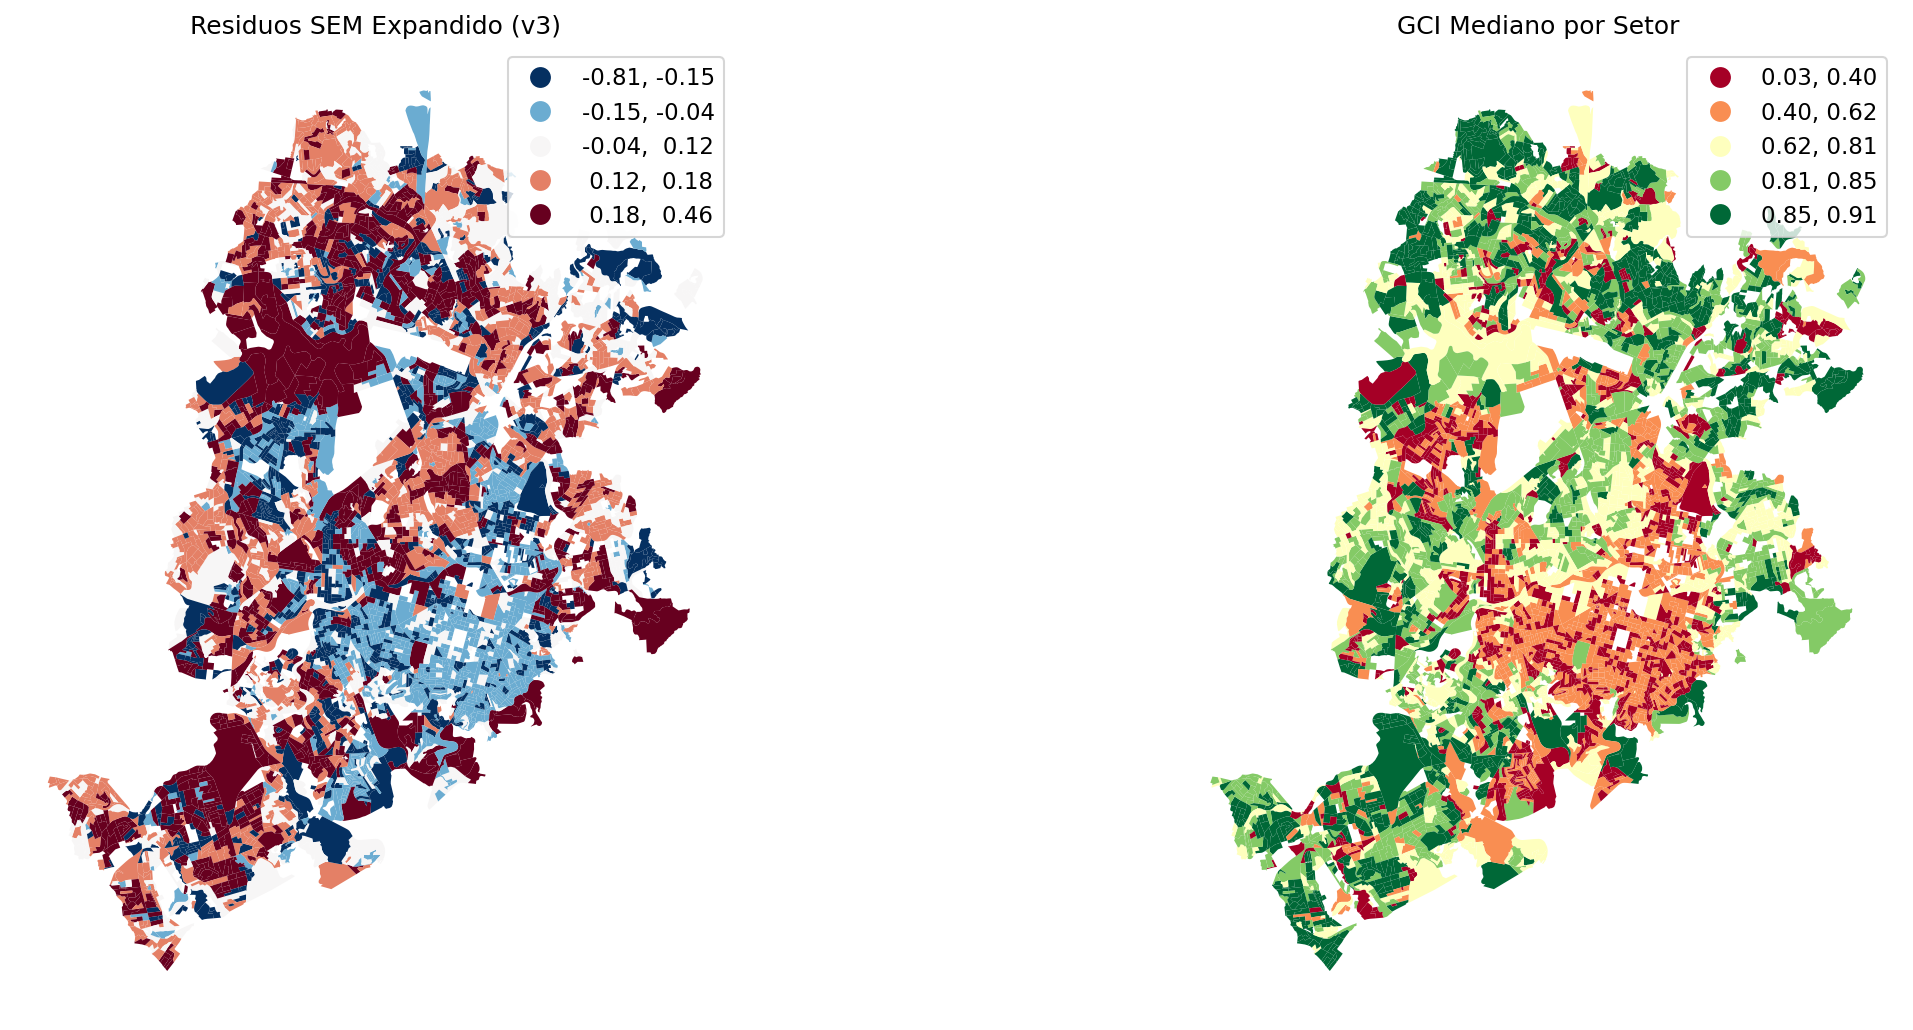

In [10]:
# D2 — SEM expandido com variaveis contextuais (IVS_SCORE, INFRA_SCORE, em_risco)
try:
    from spreg import OLS, ML_Error
    from esda.moran import Moran
    import libpysal
    import geopandas as gpd

    if 'setores_agg' not in dir() or len(setores_agg) < 10:
        raise ValueError("setores_agg nao disponivel — execute celula A1 primeiro")

    v3_path_d = config.PROCESSED_DIR / 'cnefe_master_metrics.parquet'
    if not v3_path_d.exists():
        raise FileNotFoundError("cnefe_master_metrics.parquet nao encontrado — execute --from etl")

    gdf_v3_d = gpd.read_parquet(v3_path_d)
    print(f"v3 carregado: {len(gdf_v3_d):,} registros")

    # Agregar por setor: GCI medio, IVS_SCORE medio, INFRA_SCORE medio, pct em_risco
    agg_cols_d = {'gci_med': ('GCI', 'median'), 'n': ('GCI', 'count')}
    if 'IVS_SCORE'    in gdf_v3_d.columns: agg_cols_d['ivs_med']    = ('IVS_SCORE', 'mean')
    if 'INFRA_SCORE'  in gdf_v3_d.columns: agg_cols_d['infra_med']  = ('INFRA_SCORE', 'mean')
    if 'em_risco'     in gdf_v3_d.columns: agg_cols_d['pct_risco']  = ('em_risco', 'mean')
    if 'PADRAO_SCORE' in gdf_v3_d.columns: agg_cols_d['padrao_med'] = ('PADRAO_SCORE', 'mean')

    setor_col_d = 'COD_SETOR' if 'COD_SETOR' in gdf_v3_d.columns else None
    if setor_col_d is None:
        raise ValueError("COD_SETOR nao encontrado em v3")

    agg_v3 = gdf_v3_d.groupby(setor_col_d).agg(**agg_cols_d).reset_index()

    # Normaliza COD_SETOR: registros CNEFE tem sufixos 'P'/'S' ausentes no shapefile de setores
    # (mesmo tratamento aplicado em A4 com str.rstrip('P').rstrip('S'))
    agg_v3[setor_col_d] = agg_v3[setor_col_d].astype(str).str.rstrip('PS')
    print(f"Setores unicos em v3 (apos normalizacao): {agg_v3[setor_col_d].nunique():,}")

    setores_d = setores_agg.copy()
    if 'COD_SETOR' in setores_d.columns:
        setores_d['COD_SETOR'] = setores_d['COD_SETOR'].astype(str).str.rstrip('PS')
        setores_d = setores_d.merge(agg_v3, on='COD_SETOR', how='left', suffixes=('', '_v3'))
    else:
        setores_d = setores_d.merge(agg_v3, left_on='COD_SETOR', right_on=setor_col_d,
                                    how='left', suffixes=('', '_v3'))

    print(f"Setores apos merge: {len(setores_d):,} | gci_med preenchido: {setores_d['gci_med'].notna().sum():,}")

    X_cols_d = [c for c in ['ivs_med', 'infra_med', 'pct_risco', 'padrao_med', 'n_safe']
                if c in setores_d.columns]
    if not X_cols_d:
        raise ValueError("Nenhuma feature contextual disponivel para SEM expandido")

    gci_col_d = 'gci_med' if ('gci_med' in setores_d.columns and setores_d['gci_med'].notna().any()) else 'GCI_mean'
    setores_d_clean = setores_d.dropna(subset=[gci_col_d] + X_cols_d).copy()
    setores_d_clean = setores_d_clean[setores_d_clean.geometry.is_valid].reset_index(drop=True)
    print(f"Setores com dados completos: {len(setores_d_clean):,}")

    y_d = setores_d_clean[gci_col_d].values.reshape(-1, 1)
    X_d = setores_d_clean[X_cols_d].fillna(0).values

    w_d = libpysal.weights.Queen.from_dataframe(setores_d_clean)
    w_d.transform = 'r'

    # OLS baseline
    ols_d = OLS(y_d, X_d, name_y='GCI', name_x=X_cols_d, w=w_d)
    moran_ols = Moran(ols_d.u.flatten(), w_d)
    print(f"\n=== OLS Expandido (features contextuais v3) ===")
    print(f"  R2: {ols_d.r2:.4f}")
    print(f"  AIC: {ols_d.aic:.2f}")
    print(f"  Moran I residuos: {moran_ols.I:.4f} (p={moran_ols.p_sim:.4f})")
    print(f"  Features: {X_cols_d}")

    # Spatial Error Model
    sem_d = ML_Error(y_d, X_d, w=w_d, name_y='GCI', name_x=X_cols_d)
    moran_sem_d = Moran(sem_d.u.flatten(), w_d)
    print(f"\n=== Spatial Error Model Expandido ===")
    print(f"  Lambda: {sem_d.lam:.4f}")
    print(f"  AIC: {sem_d.aic:.2f}")
    print(f"  Melhora AIC vs OLS: {ols_d.aic - sem_d.aic:.2f}")
    print(f"  Moran I residuos SEM: {moran_sem_d.I:.4f} (p={moran_sem_d.p_sim:.4f})")
    print(f"  -> Residuos {'ainda autocorrelacionados' if moran_sem_d.p_sim < 0.05 else 'limpos (sem autocorrelacao residual)'}")

    setores_d_clean = setores_d_clean.copy()
    setores_d_clean['sem_res_v3'] = sem_d.u.flatten()
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    setores_d_clean.plot(column='sem_res_v3', cmap='RdBu_r', legend=True,
                         ax=axes[0], edgecolor='none', scheme='quantiles', k=5)
    axes[0].set_title('Residuos SEM Expandido (v3)', fontsize=12)
    axes[0].set_axis_off()
    setores_d_clean.plot(column=gci_col_d, cmap='RdYlGn', legend=True,
                         ax=axes[1], edgecolor='none', scheme='quantiles', k=5)
    axes[1].set_title('GCI Mediano por Setor', fontsize=12)
    axes[1].set_axis_off()
    plt.tight_layout()
    plt.savefig(config.FIG_DIR / 'nb11_sem_expandido.png', dpi=200, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"D2 skipped: {e}")
    import traceback; traceback.print_exc()

Lambda SEM expandido = 0,6353 (vs 0,6927 no SEM básico), redução modesta. R² OLS expandido = 0,3508 com IVS, INFRA, em_risco e PADRAO. Moran I dos resíduos SEM: 0,4175 (p=0,001), ainda autocorrelacionados.

As variáveis contextuais BHMap explicam parte da variação do GCI por setor (melhora de R²), mas a autocorrelação espacial residual permanece elevada, há estrutura espacial no GCI que não é capturada por essas variáveis isoladamente.

## Conclusão do Notebook 11

Seção D complementa os resultados das análises A1–A5:
- D1 (Spearman por setor): IVS_SCORE e em_risco correlacionam negativamente com GCI_empírico; INFRA_SCORE e PADRAO_SCORE também com direção contrária ao esperado (paradoxo da infraestrutura: áreas mais infraestruturadas são mais verticalizadas)
- D2 (SEM Expandido): Lambda SEM reduz de 0,6927 para 0,6353 com variáveis contextuais. OLS expandido R²=0,3508. Resíduos ainda significativos (Moran I=0,4175, p=0,001) indicam morfologia local não completamente capturada

Resultado conjunto: qualidade CNEFE espacialmente estruturada por fatores urbanos verificados.